In [104]:
import numpy as np
import pandas as pd
from numpy.fft import fft
from matplotlib import pyplot as plt
import math
import warnings,os
import glob
from scipy.signal import find_peaks
warnings.filterwarnings('ignore')

# Gather Data points
1. Given path of the folder that contain all labels folder 
2. Each label folder contain same amount of data point file and name as output_1.csv ....output_*.csv
3. Gather all datapoints to all_result in each labels' folder.

In [395]:
path="./data/2025-2-26-contact-type/demo_data/test_set/"
folder_list = os.listdir(path)
folder_list

In [396]:
file_size=10 # the number of files in each folder
def get_data(raw_data):
  data=raw_data.drop(["msg"],axis=1)
  rot_data = data
  return rot_data
# concate all data to single file
for name_idx in range(len(folder_list)):
  df=[]
  for i in range(1,file_size+1):
    material=path+folder_list[name_idx]
    filename="/output_"+str(i)+".csv"
    temp=pd.read_csv(material+filename)
    temp=get_data(temp) # remove the unuse columns
    row_data=[]
    for row in range (len(temp)):
      row_data.append(temp.iloc[row].values)
    row_data=np.array(row_data).reshape((1,-1)).squeeze(axis=0)
    df.append(row_data)
  df=pd.DataFrame(df)
  material=path+folder_list[name_idx]
  df.transpose().to_csv(material+"/all_result.csv")
  print("finish "+folder_list[name_idx])

finishin_hole_3
finishin_hole_1
finishdiagonal_9
finishdiagonal_7
finishone_line_7
finishone_line_3
finishone_line_10
finishdiagonal_8
finishin_hole_9
finishone_line_1
finishdiagonal_6
finishdiagonal_2
finishin_hole_10
finishin_hole_2
finishdiagonal_10
finishin_hole_6
finishdiagonal_4
finishone_line_6
finishone_line_9
finishin_hole_7
finishin_hole_5
finishin_hole_8
finishone_line_5
finishin_hole_4
finishone_line_8
finishone_line_2
finishdiagonal_5
finishone_line_4
finishdiagonal_3
finishdiagonal_1


# Trianing

## Import dataset


In [433]:
import random
def import_data(name,path):
  """
  Import the data from the CSV file.
    
    Args:
        name (str): The name of the folder.
        path (str): The path of the folder.

    Returns:
        pd.DataFrame: A dataframe containing the data.
  """
  material=path+name
  filename="/all_result.csv"
  df=pd.read_csv(material+filename)
  df=df.dropna(axis=0) # drop the unconsistent data long
  df=df.drop(list(df)[0],axis=1)

  return df

In [434]:
df_all=pd.DataFrame()

In [ ]:
path="./data/2025-2-27-contact-type/demo_data/train_set/"
folder_list = os.listdir(path)
# labellist=['p'+str(i) for i in range(1,19)]
# labellist=folder_list
# labellist=['center','edge','middle']
labellist=['diagonal','one_line','in_hole']

for name in folder_list:
  df_temp=import_data(name=name,path=path)
  label=""
  for i in labellist:
    if i in name :
      label=i
      break
  if (label=='' ): continue
  print(label,name)
  df_temp.loc['label']=[labellist.index(label) for _ in list(df_temp)]
  df_all = pd.concat([df_all, df_temp], axis=1)


in_hole in_hole_3
in_hole in_hole_1
diagonal diagonal_9
diagonal diagonal_7
one_line one_line_7
one_line one_line_3
one_line one_line_10
diagonal diagonal_8
in_hole in_hole_9
one_line one_line_1
diagonal diagonal_6
diagonal diagonal_2
in_hole in_hole_10
in_hole in_hole_2
diagonal diagonal_10
in_hole in_hole_6
diagonal diagonal_4
one_line one_line_6
one_line one_line_9
in_hole in_hole_7
in_hole in_hole_5
in_hole in_hole_8
one_line one_line_5
in_hole in_hole_4
one_line one_line_8
one_line one_line_2
diagonal diagonal_5
one_line one_line_4
diagonal diagonal_3
diagonal diagonal_1


In [436]:
df_all2=pd.DataFrame()

In [437]:

path_2="./data/2025-2-27-contact-type/demo_data/test_set/"
folder_list_2 = os.listdir(path_2)
for name in folder_list_2:
  # if ('2' in name ): continue
  df_temp=import_data(name=name,path=path_2)
  label=""
  for i in labellist:
    if i in name :
      label=i
      break
  if (label==''): continue
  print(label,name)
  df_temp.loc['label']=[labellist.index(label) for _ in list(df_temp)]
  df_all2 = pd.concat([df_all2, df_temp], axis=1,ignore_index=True)

in_hole in_hole_3
in_hole in_hole_1
diagonal diagonal_9
diagonal diagonal_7
one_line one_line_7
one_line one_line_3
one_line one_line_10
diagonal diagonal_8
in_hole in_hole_9
one_line one_line_1
diagonal diagonal_6
diagonal diagonal_2
in_hole in_hole_10
in_hole in_hole_2
diagonal diagonal_10
in_hole in_hole_6
diagonal diagonal_4
one_line one_line_6
one_line one_line_9
in_hole in_hole_7
in_hole in_hole_5
in_hole in_hole_8
one_line one_line_5
in_hole in_hole_4
one_line one_line_8
one_line one_line_2
diagonal diagonal_5
one_line one_line_4
diagonal diagonal_3
diagonal diagonal_1


## Data preprocess
1. Drop the zero row
2. Clip the data to same size 
3. Use the fft to each data point 

In [444]:
df_all=df_all.dropna(axis=0)
df_all2=df_all2.dropna(axis=0)


In [447]:
def fft_self(df):
    """
    Perform FFT on each column of the dataframe and return the result.
    Args:
        df (pd.DataFrame): DataFrame containing the data.
    Returns:
        pd.DataFrame: DataFrame containing the FFT results.
    """
    data_rows = df.iloc[:-1, :]  # All rows except the last
    label_row = df.iloc[-1, :]    # Last row (label)

    # Apply FFT on each column except the last row
    fft_result = data_rows.apply(lambda col: np.abs(np.fft.fft(col)), axis=0)

    # Append the label row to the FFT result
    fft_result.loc['label'] = label_row
    return fft_result

In [ ]:
df_all = pd.concat([df_all.iloc[:42000], df_all.iloc[[-1]]], axis=0,ignore_index = True)
df_all2 = pd.concat([df_all2.iloc[:42000], df_all2.iloc[[-1]]], axis=0,ignore_index = True)
df_all=fft_self(df_all)
df_all2=fft_self(df_all2)

## Training 
1. Do the kernal PCA
2. Train with MLP model

In [426]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report
from sklearn.decomposition import KernelPCA
from sklearn.neural_network import MLPClassifier

In [427]:
df = df_all.T
X=df.drop("label",axis=1)
y=df["label"].astype(int)
df2 = df_all2.T
X2=df2.drop("label",axis=1)
y2=df2["label"].astype(int)
X.shape,y.shape,X2.shape,y2.shape

((3000, 42000), (3000,), (600, 42000), (600,))

In [ ]:
n_schedule=[809,500,100,50,25,10,5,3,2]
# n_schedule=[30]
for i in n_schedule:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=32)
    
    n_components=i    
    kernel_pca = KernelPCA(kernel='cosine',n_components=i)
    kpca=kernel_pca.fit(X_train)
    X_train=kpca.transform(X_train)
    X_test = kpca.transform(X_test)

    clf = MLPClassifier((400,250,100),random_state=1, max_iter=300).fit(X_train, y_train)
    X_test, y_test = X2,y2
    X_test = kpca.transform(X_test)
    y_pred=clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy{i}: {accuracy * 100:.2f}%")
    

# 

Accuracy809: 94.00%
Accuracy500: 94.33%
Accuracy100: 93.67%
Accuracy50: 90.33%
Accuracy25: 93.00%
Accuracy10: 88.83%
Accuracy5: 86.17%
Accuracy3: 84.33%
Accuracy2: 73.67%


## Visualize result


### Visualization of the variance after kernel pca

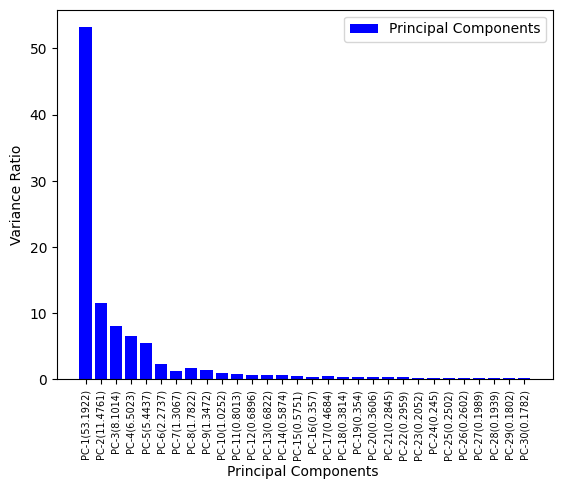

In [ ]:
 
#--------- Explained Variance Ratio ------------
explained_variance = np.var(X_test, axis=0)
ev = explained_variance / np.sum(explained_variance)
#--------- Bar Graph for Explained Variance Ratio ------------
plt.bar([i for i in range(n_components) ],list(ev*100),label='Principal Components',color='b')
plt.legend()
plt.xlabel('Principal Components ')
n=list(ev*100)
pc=[]
for i in range(len(n)):
        n[i]=round(n[i],4)
        pc.append('PC-'+str(i+1)+'('+str(n[i])+')')
plt.xticks([i for i in range(n_components) ],pc, fontsize=7, rotation=90)
plt.ylabel('Variance Ratio')
plt.show()

### Visualization of model output

In [219]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [288]:
X_test, y_test = X2,y2
X_test = kpca.transform(X_test)
y_pred=clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 100.00%


In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=labellist))
temp=classification_report(y_test, y_pred, target_names=labellist, output_dict=True)
output=pd.DataFrame(temp)

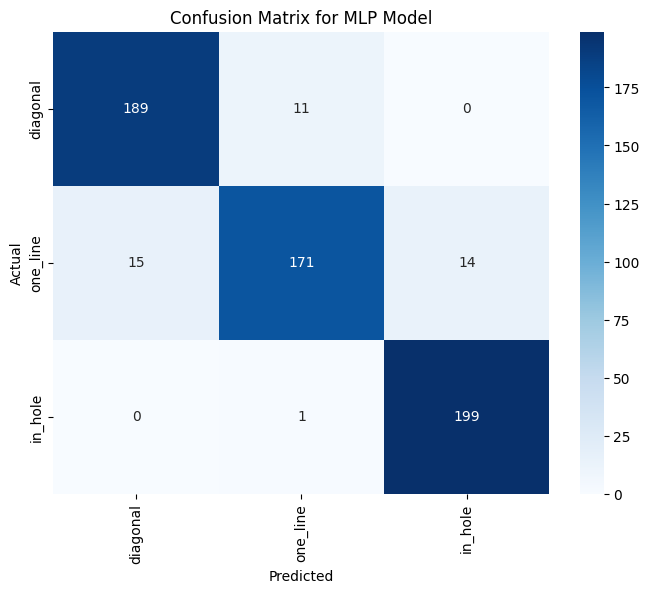

In [429]:
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labellist, yticklabels=labellist)
plt.xlabel('Predicted',)
plt.xticks(rotation=90)
plt.ylabel('Actual')
plt.title('Confusion Matrix for MLP Model')
plt.show()

### Visualization of raw data and fft data

In [449]:
def plot_raw(df):
    # Select the column from csv
    # time_column = [i for i in range(len(df))]  # Assuming the time column is the first column
    time_column=[i for i in range(len(df))]
    data_columns = [col for col in df.columns if 'data_' in col]

    plt.figure(figsize=(12, 2))

    # Plot data points for each row
    for data_col in data_columns:
        plt.scatter(time_column, df[data_col], s=1)  # use scatter, s controls the size of point

    # plt.title('Signal Plot over Time')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Signal Value (mV)')   # After amplified

    plt.grid(True)
    plt.ylim(-1300, 1300)

    plt.show()

In [ ]:
from scipy.fft import fft


def plot_fft(df, title='FFT of Aluminum stick downsampling to 500 points'):
    # Process data, connect every message together
    data_columns1 = [col for col in df.columns if 'data_' in col]
    data1 = df[data_columns1].values.flatten()  # flatten data point

    # Apply Savitzky-Golay filter or Median filter (uncomment them if use it)
    # data1 = savgol_filter(data1, window_length, polyorder)
    # data1 = medfilt(data1, kernel_size=kernel_size)

    # Apply Hann window (uncomment them if use it)
    # window = windows.hann(len(data1))  # Ensure window length matches data length
    # data1 = data1 * window

    # Run FFT
    fft_result1 = fft(data1)

    # Calculate frequency
    sample_rate = 44100
    freq1 = np.fft.fftfreq(data1.size, d=1/sample_rate)

    # Select positive frequency part
    positive_freq_indices1 = freq1 > 0
    positive_freqs1 = freq1[positive_freq_indices1]
    positive_fft_result1 = fft_result1[positive_freq_indices1]

    # Downsample the FFT result
    resolution = 500  # Number of frequency bins,  default: 220479
    if len(positive_freqs1) > resolution:
        step = max(len(positive_freqs1) // resolution, 1)  # Ensure step is at least 1
        print("Number of bins:", resolution)
        print("step:", step)
        downsampled_freqs1 = positive_freqs1[::step]
        downsampled_fft_result1 = positive_fft_result1[::step]
    else:
        print(positive_freqs1.size)
        downsampled_freqs1 = positive_freqs1
        downsampled_fft_result1 = positive_fft_result1


    # Plot
    plt.figure(figsize=(15, 3))  # Create a single plot
    plt.plot(downsampled_freqs1, np.abs(downsampled_fft_result1))  # freq vs amplitude
    plt.title(title)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.xlim(0, 20500)  # Set x-axis limits as needed
    plt.ylim(0, 300000)  # Adjust y-axis limits as needed

    plt.grid(True)
    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.show()

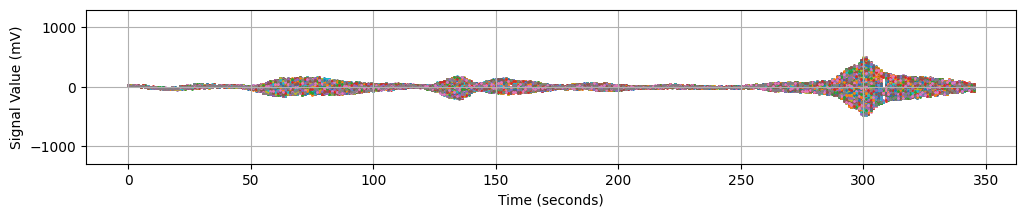

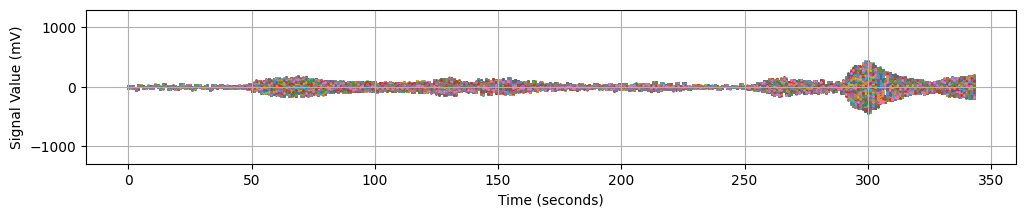

In [ ]:
data_file_path="./data/feb_18_data/internal_structure/cylinder_2/p1/output_1.csv"
p1 = pd.read_csv(data_file_path)
plot_raw(p1)

data_file_path="./data/feb_18_data/test_25_each_label/internal_structure/cylinder_2/p10/output_1.csv"
p10 = pd.read_csv(data_file_path)
plot_raw(p10)